In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df= pd.read_csv('ab_test.csv')
df.head

<bound method NDFrame.head of             id     time  con_treat      page  converted
0       851104  11:48.6    control  old_page          0
1       804228  01:45.2    control  old_page          0
2       661590  55:06.2  treatment  new_page          0
3       853541  28:03.1  treatment  new_page          0
4       864975  52:26.2    control  old_page          1
...        ...      ...        ...       ...        ...
294473  751197  28:38.6    control  old_page          0
294474  945152  51:57.1    control  old_page          0
294475  734608  45:03.4    control  old_page          0
294476  697314  20:29.0    control  old_page          0
294477  715931  40:24.5  treatment  new_page          0

[294478 rows x 5 columns]>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [5]:
df.isnull().sum()

id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

In [ ]:
df['con_treat'].value_counts() #Checking for the Group size

con_treat
treatment    147276
control      147202
Name: count, dtype: int64

In [ ]:
df['converted'].mean()  #The overall conversion rate

np.float64(0.11965919355605512)

In [ ]:
df.groupby('con_treat')['converted'].mean() # the conversion rate of each group 

con_treat
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

In [9]:
# Calculating the lift
control_rate = df[df['con_treat'] == 'control']['converted'].mean()
treatment_rate = df[df['con_treat'] == 'treatment']['converted'].mean()

lift = (treatment_rate - control_rate) / control_rate * 100

print(f"Control Conversion Rate: {control_rate:.4f}")
print(f"Treatment Conversion Rate: {treatment_rate:.4f}")
print(f"Lift: {lift:.4f}%")

Control Conversion Rate: 0.1204
Treatment Conversion Rate: 0.1189
Lift: -1.2289%


In [10]:
from statsmodels.stats.proportion import proportions_ztest

# Get number of conversions and total users per group
control_converted = df[df['con_treat'] == 'control']['converted'].sum()
treatment_converted = df[df['con_treat'] == 'treatment']['converted'].sum()

control_total = df[df['con_treat'] == 'control']['converted'].count()
treatment_total = df[df['con_treat'] == 'treatment']['converted'].count()

# Run the Z-test
count = np.array([treatment_converted, control_converted])
nobs = np.array([treatment_total, control_total])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Control Conversions: {control_converted} out of {control_total}")
print(f"Treatment Conversions: {treatment_converted} out of {treatment_total}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Control Conversions: 17723 out of 147202
Treatment Conversions: 17514 out of 147276
Z-statistic: -1.2369
P-value: 0.2161


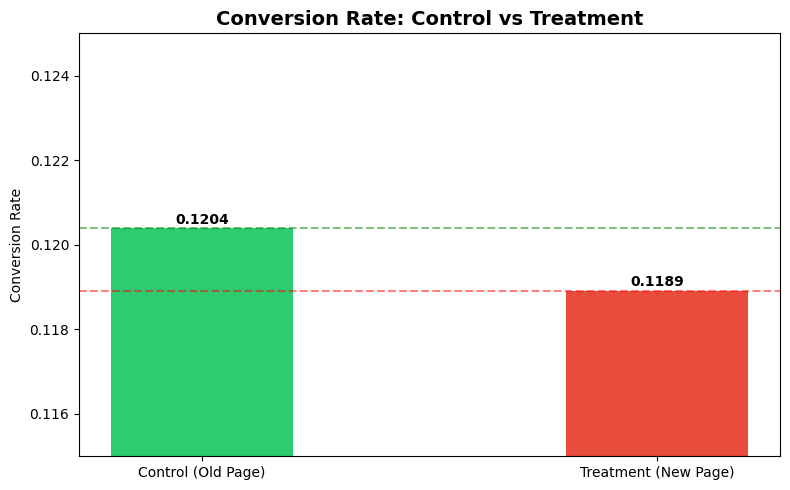

In [11]:
plt.figure(figsize=(8,5))
groups = ['Control (Old Page)', 'Treatment (New Page)']
rates = [control_rate, treatment_rate]
colors = ['#2ecc71', '#e74c3c']

plt.bar(groups, rates, color=colors, width=0.4)
plt.axhline(y=control_rate, color='green', linestyle='--', alpha=0.5)
plt.axhline(y=treatment_rate, color='red', linestyle='--', alpha=0.5)
plt.title('Conversion Rate: Control vs Treatment', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate')
plt.ylim(0.115, 0.125)

for i, v in enumerate(rates):
    plt.text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

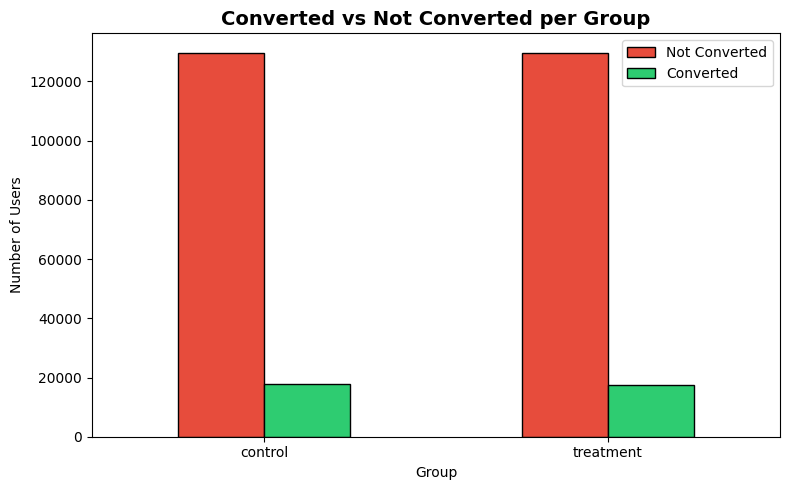

In [12]:
converted_data = df.groupby('con_treat')['converted'].value_counts().unstack()
converted_data.plot(kind='bar', figsize=(8,5), color=['#e74c3c','#2ecc71'], 
                    edgecolor='black')
plt.title('Converted vs Not Converted per Group', fontsize=14, fontweight='bold')
plt.xlabel('Group')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.legend(['Not Converted', 'Converted'])
plt.tight_layout()
plt.show()

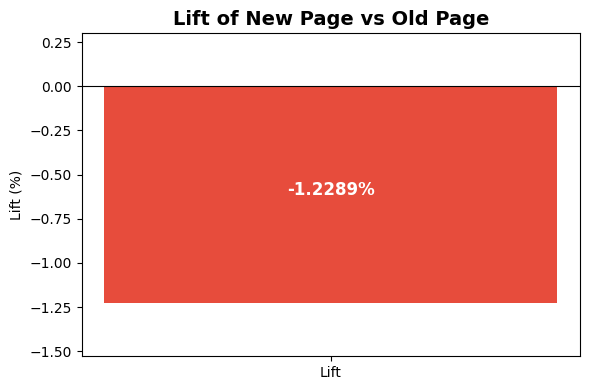

In [14]:
plt.figure(figsize=(6,4))
plt.bar(['Lift'], [lift], color='#e74c3c', width=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Lift of New Page vs Old Page', fontsize=14, fontweight='bold')
plt.ylabel('Lift (%)')
plt.ylim(lift - 0.3, 0.3)
plt.text(0, lift/2, f'{lift:.4f}%', ha='center', fontweight='bold', 
         color='white', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
results = pd.DataFrame({
    'Metric': ['Z-Statistic', 'P-Value', 'Lift', 
                'Control Rate', 'Treatment Rate'],
    'Value': [z_stat, p_value, lift, 
               control_rate, treatment_rate]
})

results.to_csv('ab_test_results.csv', index=False)

In [16]:
kpi_data = pd.DataFrame({
    'Metric': ['P-Value', 'P-Value'],
    'Value': [0.2161, 0.05],
    'Type': ['Actual', 'Target']
})

kpi_data.to_csv('kpi_data.csv', index=False)

In [18]:
kpi_data2 = pd.DataFrame({
    'Metric': ['P-Value', 'P-Value'],
    'Value': [0.2161, 0.05],
    'Type': ['Actual', 'Target'],
    'Period': [1, 2]  # simple sequential numbers
})

kpi_data.to_csv('kpi_data2.csv', index=False)